# eCPA Flash — interactive tutorial

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jmoortgat/CPA_and_eCPA_flash/blob/main/notebooks/ecpa_flash_tutorial.ipynb)

This notebook is a hands-on user manual for the
[`CPA_and_eCPA_flash`](https://github.com/jmoortgat/CPA_and_eCPA_flash) package:
phase-stability and two-phase flash calculations for CO$_2$ + H$_2$O + NaCl
mixtures with the (electrolyte) Cubic-Plus-Association equation of state.
It walks through the basic workflows step by step:

Single flash calculations with **CPA** (salt-free) and **eCPA** (brine),
pressure sweeps at fixed temperature compared against experimental data,
CO$_2$ solubility in NaCl brines of different salinity, phase densities,
and warm-started high-throughput calls.

Every cell runs live — on your machine or on Google Colab via the badge above.
A complete reproduction of the companion paper (all figures and tables) is in
[`ecpa_flash_paper.ipynb`](https://github.com/jmoortgat/CPA_and_eCPA_flash/blob/main/notebooks/ecpa_flash_paper.ipynb);
per-figure scripts are indexed in
[`REPRODUCING_FIGURES.md`](https://github.com/jmoortgat/CPA_and_eCPA_flash/blob/main/REPRODUCING_FIGURES.md).

**Contents**

1. [Getting started](#sec1)
2. [Package orientation](#sec2)
3. [Salt-free flash with CPA](#sec3)
4. [Brine flash with eCPA](#sec4)
5. [Isotherms vs experimental data: CO$_2$–H$_2$O](#sec5)
6. [CO$_2$ solubility in NaCl brines](#sec6)
7. [Phase densities](#sec7)
8. [Performance and warm starts](#sec8)
9. [Going further](#sec9)

<a id="sec1"></a>
## 1. Getting started

The cell below prepares the environment. On **Colab** it clones the repository
(shallow) and moves into its `code/` directory; **locally** it locates the
repository root from wherever the notebook was launched. All package code is
imported straight from the source tree, so no installation step is required
(the package can also be installed with `pip install -e .` from the repository
root — see the README).

In [4]:
import os, sys, pathlib, subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not pathlib.Path("CPA_and_eCPA_flash").exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/jmoortgat/CPA_and_eCPA_flash.git"],
                       check=True)
    os.chdir("CPA_and_eCPA_flash/code")
else:
    here = pathlib.Path.cwd()
    for cand in (here, *here.parents):
        if (cand / "code" / "ecpa").is_dir():
            os.chdir(cand / "code"); break
        if (cand / "ecpa").is_dir() and (cand / "CPA.py").exists():
            os.chdir(cand); break
sys.path.insert(0, os.getcwd())
print("Ready — working from the repository's", pathlib.Path.cwd().name + "/ directory")

Ready — working from the repository's code/ directory


In [5]:
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Journal-style defaults: bold, large fonts, thick frames, colorblind-safe palette
mpl.rcParams.update({
    "font.size": 13, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "font.weight": "bold", "axes.labelweight": "bold",
    "axes.linewidth": 1.6, "axes.edgecolor": "black",
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.major.size": 6, "ytick.major.size": 6,
    "xtick.direction": "in", "ytick.direction": "in",
    "lines.linewidth": 2.2, "lines.markersize": 6,
    "legend.frameon": True, "legend.edgecolor": "black",
    "savefig.dpi": 150, "savefig.bbox": "tight",
})
WONG = ["#000000", "#E69F00", "#56B4E9", "#009E73",
        "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
LS   = ["-", "--", "-.", ":"]

# The two flash entry points and their helpers
import CPA                                      # salt-free CPA flash (CO2 + H2O)
from ecpa.flash import flash_co2_h2o_salt_kv    # eCPA brine flash (CO2 + H2O + NaCl)
from ecpa.stability import ecpa_stability_flash # stability + flash driver
from ecpa.parameters import make_params         # eCPA parameter dictionary
from ecpa.warmstart import ScanTableWarmStart   # precomputed solution table
from ecpa.utils import print_flash_report       # formatted result summary

M_H2O = 0.01801528   # kg/mol — converts mole fractions to molality
print("Imports OK")

Imports OK


<a id="sec2"></a>
## 2. Package orientation

The repository ships two solvers that share the same physics but target
different systems:

| Entry point | System | Where |
|---|---|---|
| `CPA.flash_co2_h2o_tpz_robust(T, P_bar, z_co2)` | CO$_2$ + H$_2$O (salt-free) | `code/CPA.py` |
| `ecpa.flash.flash_co2_h2o_salt_kv(T, P_bar, z_co2, m_tot)` | CO$_2$ + H$_2$O + NaCl | `code/ecpa/flash.py` |
| `ecpa.stability.ecpa_stability_flash(z_co2, ms, T, P)` | stability test + flash (eCPA) | `code/ecpa/stability.py` |

**Conventions used throughout:**

- Temperature `T` in **kelvin**, pressure `P_bar` in **bar**.
- `z_co2` is the CO$_2$ mole fraction of the **salt-free feed** (CO$_2$ + H$_2$O
  only); salt enters separately as the prepared molality `m_tot` in
  **mol NaCl per kg of water**.
- Component indexing in eCPA results: 1 = H$_2$O, 2 = Na$^+$, 3 = Cl$^-$,
  4 = CO$_2$. So `x_aq["x4w"]` is the CO$_2$ mole fraction in the aqueous
  phase and `x_c["x1c"]` is the water content of the CO$_2$-rich phase.
- `beta` is the mole fraction of the CO$_2$-rich phase.

The salt is a nonvolatile solute: it stays entirely in the aqueous phase, and
because dissolved CO$_2$ removes some water into the CO$_2$-rich phase, the
*equilibrium* aqueous molality `ms_aq` ends up slightly higher than the
prepared `m_tot` (more on this in [section 4](#sec4)).

<a id="sec3"></a>
## 3. Salt-free flash with CPA

### 3.1 A single two-phase flash

`CPA.flash_co2_h2o_tpz_robust` is the hierarchical TPz flash for the binary:
it first runs a Michelsen tangent-plane-distance (TPD) **stability test** with
six initial guesses, and only if the feed is unstable proceeds to the
**two-phase flash** (accelerated successive substitution with a Newton
finish). Here: 30 mol% CO$_2$ at 50 °C and 100 bar — deep inside the
two-phase region.

In [8]:
out = CPA.flash_co2_h2o_tpz_robust(T=323.15, P_bar=100.0, z_co2=0.30)

print("phase          :", out["phase"])
print("beta           : %.4f    (mole fraction of the CO2-rich phase)" % out["beta"])
print("aqueous x      : CO2 = %.5f   H2O = %.5f" % tuple(out["x"]))
print("CO2-rich y     : CO2 = %.5f   H2O = %.5f" % tuple(out["y"]))
print("density [kg/m3]: aq  = %.1f      CO2-rich = %.1f"
      % (1000 * out["tie"]["rho_mass"][0], 1000 * out["tie"]["rho_mass"][1]))
print("solver         : %d SSI + %d Newton iterations, residual %.1e"
      % (out["tie"]["ssi_iterations"], out["tie"]["newton_iterations"],
         out["tie"]["residual_norm"]))

phase          : two_phase
beta           : 0.2851    (mole fraction of the CO2-rich phase)
aqueous x      : CO2 = 0.02195   H2O = 0.97805
CO2-rich y     : CO2 = 0.99717   H2O = 0.00283
density [kg/m3]: aq  = 999.0      CO2-rich = 369.9
solver         : 7 SSI + 2 Newton iterations, residual 4.6e-11


The result is a plain dictionary. The parts you will use most:

- `out["phase"]` — `"two_phase"` or `"single_phase"`.
- `out["x"]`, `out["y"]` — aqueous and CO$_2$-rich compositions as
  `[x_CO2, x_H2O]` arrays. `x[0]` is the **CO$_2$ solubility** and `y[1]` the
  **water content of the CO$_2$-rich phase** — the two quantities usually
  compared against experiments.
- `out["tie"]` — solver details: compressibility factors `Z`, mass densities
  `rho_mass` (g/cm$^3$), iteration counts, and the converged K-values.

### 3.2 When the feed is stable

Dissolve only 0.5 mol% CO$_2$ at the same conditions and the mixture stays a
single liquid: the stability test finds no trial composition with a negative
tangent-plane distance, and no flash is attempted.

In [10]:
dilute = CPA.flash_co2_h2o_tpz_robust(T=323.15, P_bar=100.0, z_co2=0.005)

print("phase   :", dilute["phase"])
print("tpd_min : %9.2e" % dilute["stability"]["tpd_min"])
for name, tpd, conv, iters in dilute["stability"]["trials"]:
    print("  trial %-14s tpd = %9.2e   (%2d iterations)" % (name, tpd, iters))

phase   : single_phase
tpd_min : -4.44e-16
  trial Wilson         tpd = -4.44e-16   (11 iterations)
  trial 1/Wilson       tpd =  1.55e-15   ( 8 iterations)
  trial Wilson^1/3     tpd =  5.11e-15   ( 8 iterations)
  trial 1/Wilson^1/3   tpd =  1.22e-15   ( 6 iterations)
  trial CO2-rich       tpd =  7.32e-01   (12 iterations)
  trial H2O-rich       tpd = -2.22e-16   (13 iterations)


No trial finds a negative tangent-plane distance: most collapse back to the
feed composition (TPD zero to machine precision — the trivial solution) and
the CO$_2$-rich trial lands at a clearly positive TPD, so the single phase is
confirmed stable. In the two-phase case of section 3.1 it is the most
*negative* trial that supplies the initial K-values for the flash — that is
the "hierarchical" part of the algorithm.

<a id="sec4"></a>
## 4. Brine flash with eCPA

### 4.1 A single brine flash

For salty systems the eCPA equation of state adds Debye–Hückel and Born
electrostatic terms and an ion-perturbed permittivity. The K-value flash
`flash_co2_h2o_salt_kv` takes the same `(T, P, z)` inputs plus the prepared
NaCl molality `m_tot`, and `print_flash_report` gives a formatted summary:

In [13]:
out = flash_co2_h2o_salt_kv(373.15, 200.0, 0.30, 1.0)   # T [K], P [bar], z_CO2, m [mol/kg]
print_flash_report(out)


================ FLASH RESULT ================

  T = 373.15 K          P = 200.00 bar
  z_CO2 (feed)  =  30.00%    m_tot = 1.0000 mol/kg
  n_salt (basis)= 1.2600e-02 mol

-------- Phase Split --------
  beta  (CO2-rich fraction) =  28.68%
  N_aq  = 7.3118e-01 mol     N_c = 2.9402e-01 mol

-------- Aqueous Phase --------
  ms_aq = 1.0078 mol/kg    Z_aq = 0.127586
  rho   = 950.2 kg/m³    (5.0525e+04 mol/m³)
  V_aq  = 1.4472e-05 m³    S_aq =  34.46%
  x_H2O =  94.99%   x_CO2 =   1.56%
  x_Na+ =   1.72%   x_Cl- =   1.72%
  n_H2O = 0.6946 mol   n_CO2 = 0.0114 mol
  n_Na+ = 0.0126 mol   n_Cl- = 0.0126 mol

-------- CO2-Rich Phase --------
  Z_c   = 0.603435
  rho   = 465.0 kg/m³    (1.0683e+04 mol/m³)
  V_c   = 2.7523e-05 m³    S_c  =  65.54%
  x_H2O =   1.84%   x_CO2 =  98.16%
  n_H2O = 0.0054 mol   n_CO2 = 0.2886 mol

-------- Mass Balance --------
  H2O : 7.0000e-01 mol  (target 7.0000e-01)
  CO2 : 3.0000e-01 mol  (target 3.0000e-01)
  salt: 1.2600e-02  mol  (target 1.2600e-02)

------

Reading the report:

- The **aqueous phase** carries all the ions (`x2w` = Na$^+$, `x3w` =
  Cl$^-$) plus dissolved CO$_2$ (`x4w`); the **CO$_2$-rich phase** contains
  only CO$_2$ and water vapor.
- `ms_aq` is the *equilibrium* molality — note it exceeds the prepared
  1.0 mol/kg. The flash conserves salt: as CO$_2$-rich phase forms it strips
  water from the brine, concentrating the salt that stays behind. This
  self-consistent coupling between the phase split and the salinity is solved
  internally (it is what makes the electrolyte flash harder than running an
  EoS at fixed composition).
- Saturations, densities, and a mass-balance check close out the report.

### 4.2 How the salt concentrates

Sweep the feed CO$_2$ fraction at fixed prepared molality: the more CO$_2$-rich
phase forms (larger `beta`), the more water it removes, and the higher the
equilibrium molality climbs.

In [15]:
print(" z_CO2    beta     ms_aq [mol/kg]")
for z in (0.05, 0.2, 0.4, 0.6, 0.8):
    r = flash_co2_h2o_salt_kv(373.15, 200.0, z, 1.0)
    print(" %4.2f   %6.4f      %.4f" % (z, r["beta"], r["ms_aq"]))

 z_CO2    beta     ms_aq [mol/kg]
 0.05   0.0339      1.0007
 0.20   0.1851      1.0044
 0.40   0.3892      1.0124
 0.60   0.5962      1.0286
 0.80   0.8061      1.0806


### 4.3 The production entry point: stability + flash

In applications you rarely know beforehand whether a feed splits into two
phases. `ecpa_stability_flash` is the driver used in the validation study and
in the reservoir simulator: TPD stability analysis first, flash only when
needed. Check `r["stable"]` (or `r["phase"]`) to see which branch you got:

In [17]:
for z in (0.001, 0.30):
    r = ecpa_stability_flash(z_co2=z, ms=1.0, T=373.15, P=200.0)
    if r.get("stable"):
        print("z_CO2 = %.3f : stable single phase (all CO2 dissolves)" % z)
    else:
        print("z_CO2 = %.3f : two phases, beta = %.4f, ms_aq = %.4f mol/kg"
              % (z, r["beta"], r["ms_aq"]))

z_CO2 = 0.001 : stable single phase (all CO2 dissolves)
z_CO2 = 0.300 : two phases, beta = 0.2868, ms_aq = 1.0078 mol/kg


<a id="sec5"></a>
## 5. Isotherms vs experimental data: CO$_2$–H$_2$O

The repository includes the full experimental database used in the companion
paper (`EXP/` directory, parsed by `ecpa.exp_data.load_exp_data`): more than
1,100 measurements of CO$_2$ solubility `xc_W` and water content `yw_C`
across 273–623 K.

A pressure sweep at fixed temperature is just a loop over flash calls. In the
two-phase region the aqueous composition is independent of the feed `z_co2`
(the tie line is fixed by `T` and `P`), so a single feed of 30 mol% CO$_2$
traces the whole solubility curve. Points where the flash reports a single
phase are simply skipped.

One practical idiom: the flash labels its two phases `x` and `y` by which
side of the tie line the solver converged from, so at hot, low-pressure
conditions (steam-rich CO$_2$ phase) the slots can come out swapped.
**Identify the aqueous phase by its water content**, never by position — the
small helper below does exactly that, and also returns the matching mass
densities:

Loaded CO2/CO2_WATER_exp.parquet  (631 rows)


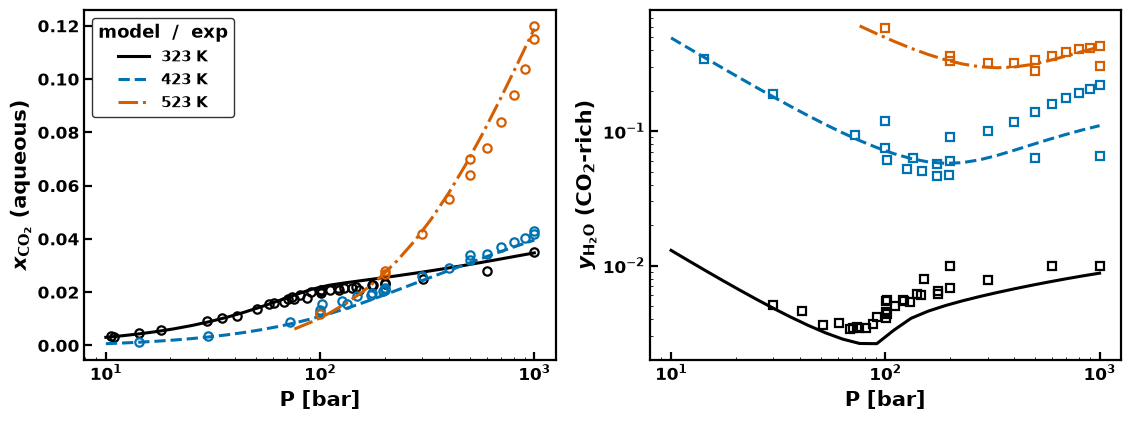

In [19]:
def cpa_phases(r):
    """Split a two-phase CPA result into (aqueous, CO2-rich) parts.

    Returns (x_aq, y_c, rho_aq, rho_c): compositions as [x_CO2, x_H2O]
    arrays and mass densities in kg/m3, with the aqueous phase identified
    as the one richer in water."""
    x, y = r["x"], r["y"]
    rho_x, rho_y = 1000 * r["tie"]["rho_mass"][0], 1000 * r["tie"]["rho_mass"][1]
    if x[1] < y[1]:
        x, y, rho_x, rho_y = y, x, rho_y, rho_x
    return x, y, rho_x, rho_y

from ecpa.exp_data import load_exp_data
exp, _ = load_exp_data()

temps  = [323.15, 423.15, 523.15]
P_grid = np.geomspace(10.0, 1000.0, 26)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for i, T in enumerate(temps):
    Px, xs, Py, ys = [], [], [], []
    for P in P_grid:
        r = CPA.flash_co2_h2o_tpz_robust(T=T, P_bar=P, z_co2=0.30)
        if r["phase"] == "two_phase":
            x_aq, y_c, _, _ = cpa_phases(r)
            Px.append(P); xs.append(x_aq[0])   # CO2 solubility in water
            Py.append(P); ys.append(y_c[1])    # water in the CO2-rich phase
    c = WONG[[0, 5, 6][i]]
    axes[0].plot(Px, xs, LS[i], color=c, label="%.0f K" % T)
    axes[1].plot(Py, ys, LS[i], color=c)
    e = exp[(np.abs(exp["T_K"] - T) < 1.0) & (exp["P_bar"] <= 1000)]
    axes[0].plot(e["P_bar"], e["xc_W"], "o", mfc="none", mew=1.6, ls="none", color=c)
    axes[1].plot(e["P_bar"], e["yw_C"], "s", mfc="none", mew=1.6, ls="none", color=c)

axes[0].set(xscale="log", xlabel="P [bar]", ylabel=r"$x_{\mathrm{CO_2}}$ (aqueous)")
axes[1].set(xscale="log", yscale="log", xlabel="P [bar]",
            ylabel=r"$y_{\mathrm{H_2O}}$ (CO$_2$-rich)")
axes[0].legend(loc="upper left", title="model  /  exp")
plt.tight_layout(); plt.show()

Lines are the CPA model; open symbols are the experimental data at the same
temperatures. The left panel shows the familiar solubility isotherms with
their plateau above the CO$_2$ critical pressure; the right panel shows the
water content of the CO$_2$-rich phase, including its characteristic minimum
and high-pressure upturn. The companion paper quantifies the agreement (6.5%
average absolute relative error over the full database) — here the point is
simply that a validation-quality comparison takes about ten lines.

<a id="sec6"></a>
## 6. CO$_2$ solubility in NaCl brines

### 6.1 Warm starts

A cold-started eCPA flash spends most of its time in successive-substitution
iterations from generic Wilson-type initial guesses. The repository ships a
precomputed 4D solution table (`code/results/scan_v4_table.npz`, spanning the
full validated $T$–$P$–$z$–$m$ range) that provides initial K-values and
phase-composition guesses for any nearby state, cutting the iteration count
— and the runtime — by roughly 3× ([section 8](#sec8) times it live). Wrap
the lookup and the flash into a small helper — this is the recommended
pattern for any sweep:

In [22]:
params = make_params()
ws = ScanTableWarmStart.load("results/scan_v4_table.npz")

def brine_flash(T, P, z_co2, m):
    """eCPA flash, warm-started from the precomputed solution table."""
    g  = ws(T, P, z_co2, m)
    kw = {} if g is None else dict(K_init=g.K_init, sol_aq_x0=g.sol_aq_x0,
                                   sol_c_x0=g.sol_c_x0)
    return flash_co2_h2o_salt_kv(T, P, z_co2, m, params=params, **kw)

def mc_of(out):
    """CO2 molality in the aqueous phase [mol per kg of water]."""
    return out["x_aq"]["x4w"] / (out["x_aq"]["x1w"] * M_H2O)

r = brine_flash(373.15, 200.0, 0.30, 1.0)
print("CO2 molality at 373 K, 200 bar, 1 mol/kg NaCl: %.4f mol/kg" % mc_of(r))

CO2 molality at 373 K, 200 bar, 1 mol/kg NaCl: 0.9109 mol/kg


### 6.2 Salinity ladder vs experimental data

The NaCl database (`ecpa.validate_nacl.load_co2nacl_exp`, 708 points) is
richest at 373 K, with full isotherms at 1, 3, and 5 mol/kg. Sweep pressure
for each brine recipe — plus the salt-free CPA curve as reference — and
overlay the measurements. Solubilities are compared as CO$_2$ molality, the
unit most brine experiments report.

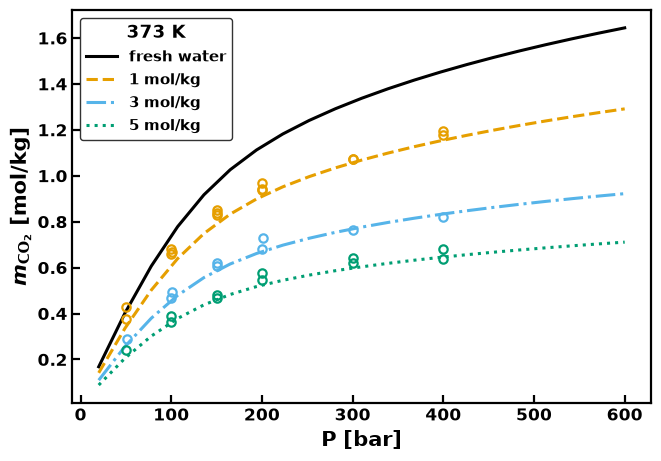

In [24]:
from ecpa.validate_nacl import load_co2nacl_exp
expb   = load_co2nacl_exp()
mc_exp = expb[expb["qty"] == "mc"]

T       = 373.15
P_grid  = np.linspace(20.0, 600.0, 21)
recipes = [0.0, 1.0, 3.0, 5.0]

fig, ax = plt.subplots(figsize=(6.8, 4.8))
for i, m in enumerate(recipes):
    mcs = []
    for P in P_grid:
        if m == 0.0:
            r = CPA.flash_co2_h2o_tpz_robust(T=T, P_bar=P, z_co2=0.30)
            if r["phase"] != "two_phase":
                mcs.append(np.nan); continue
            x_aq, _, _, _ = cpa_phases(r)
            mcs.append(x_aq[0] / (x_aq[1] * M_H2O))
        else:
            r = brine_flash(T, P, 0.30, m)
            mcs.append(mc_of(r) if r.get("phase") != "single_phase" else np.nan)
    lbl = "fresh water" if m == 0 else "%.0f mol/kg" % m
    ax.plot(P_grid, mcs, LS[i], color=WONG[i], label=lbl)
    e = mc_exp[(np.abs(mc_exp["T_K"] - T) < 2.0)
               & (np.abs(mc_exp["ms"] - m) < 0.05) & (mc_exp["P_bar"] <= 600)]
    ax.plot(e["P_bar"], e["value"], "o", mfc="none", mew=1.6, ls="none", color=WONG[i])

ax.set(xlabel="P [bar]", ylabel=r"$m_{\mathrm{CO_2}}$ [mol/kg]")
ax.legend(loc="upper left", title="373 K")
plt.tight_layout(); plt.show()

Salting-out at a glance: each mole of NaCl per kilogram of water pushes the
whole solubility isotherm down, and the model tracks the measurements across
the ladder with no parameters adjusted to these data.

### 6.3 The salting-out curve

Fixing `T` and `P` and sweeping the brine recipe isolates the effect:

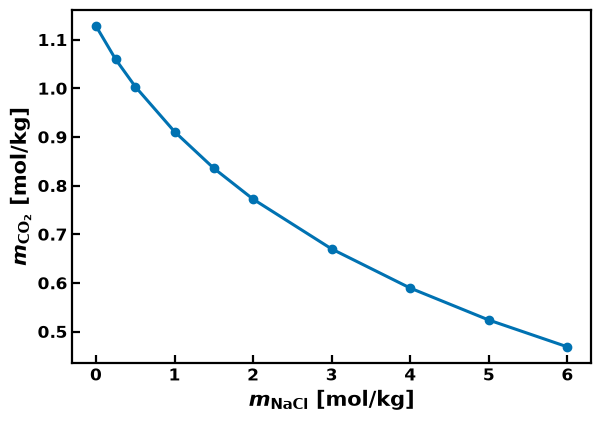

Solubility at 6 mol/kg is 42% of the fresh-water value.


In [26]:
T, P   = 373.15, 200.0
m_grid = np.array([0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0])

mcs = []
for m in m_grid:
    if m == 0.0:
        x_aq, _, _, _ = cpa_phases(CPA.flash_co2_h2o_tpz_robust(T=T, P_bar=P, z_co2=0.30))
        mcs.append(x_aq[0] / (x_aq[1] * M_H2O))
    else:
        mcs.append(mc_of(brine_flash(T, P, 0.30, m)))
mcs = np.array(mcs)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(m_grid, mcs, "-", color=WONG[5], marker="o")
ax.set(xlabel=r"$m_{\mathrm{NaCl}}$ [mol/kg]", ylabel=r"$m_{\mathrm{CO_2}}$ [mol/kg]")
plt.tight_layout(); plt.show()

print("Solubility at 6 mol/kg is %.0f%% of the fresh-water value."
      % (100 * mcs[-1] / mcs[0]))

<a id="sec7"></a>
## 7. Phase densities

Densities follow directly from the converged compressibility factors:
$\rho = P\,\bar{M} / (Z R T)$ with the phase molar mass $\bar{M}$ from the
equilibrium composition. For the salt-free binary they are already part of
the result (`tie["rho_mass"]`, in g/cm$^3$), and the `cpa_phases` helper from
[section 5](#sec5) returns them phase-matched. Sweeping pressure at 323 K
shows the contrast that drives buoyant CO$_2$ migration in storage settings:
a stiff, barely compressible aqueous phase next to a CO$_2$-rich phase whose
density climbs steeply through the CO$_2$ critical pressure.

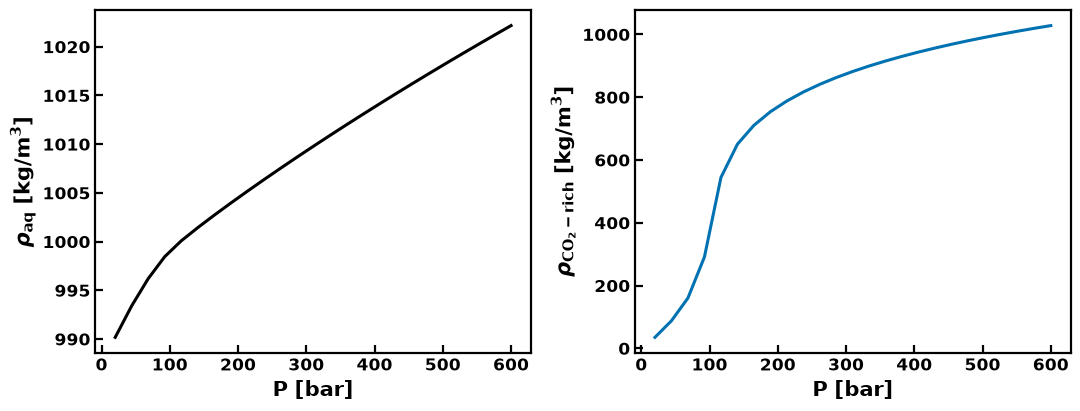

In [28]:
P_grid = np.linspace(20.0, 600.0, 25)
Ps, rho_aq, rho_c = [], [], []
for P in P_grid:
    r = CPA.flash_co2_h2o_tpz_robust(T=323.15, P_bar=P, z_co2=0.30)
    if r["phase"] != "two_phase":
        continue
    _, _, ra, rc = cpa_phases(r)
    Ps.append(P); rho_aq.append(ra); rho_c.append(rc)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
axes[0].plot(Ps, rho_aq, "-", color=WONG[0])
axes[1].plot(Ps, rho_c, "-", color=WONG[5])
axes[0].set(xlabel="P [bar]", ylabel=r"$\rho_{\mathrm{aq}}$ [kg/m$^3$]")
axes[1].set(xlabel="P [bar]", ylabel=r"$\rho_{\mathrm{CO_2-rich}}$ [kg/m$^3$]")
plt.tight_layout(); plt.show()

Against the IAPWS-95 reference, pure-water density is accurate to 0.30% on
average over 475 liquid conditions when the paper's temperature-dependent
Péneloux volume shift for H$_2$O is applied
(`code/scripts/benchmark_pure_water_density.py` reproduces that comparison;
the densities plotted above are unshifted EoS values). Note a scope limit:
the eCPA volumes in this release are not calibrated against *brine* density
data, so densities reported for salty systems (e.g. by `print_flash_report`)
should be treated as EoS-consistent values rather than density predictions;
density-targeted volume corrections are part of the companion work on
multi-salt brines.

<a id="sec8"></a>
## 8. Performance and warm starts

The warm-start table from [section 6](#sec6) is what makes the eCPA flash fast
enough for simulation workloads. Timing the same state cold and warm:

In [31]:
T, P, z, m = 350.0, 150.0, 0.40, 2.0
flash_co2_h2o_salt_kv(T, 140.0, z, m, params=params)   # warm up module caches

t0 = time.perf_counter()
cold = flash_co2_h2o_salt_kv(T, P, z, m, params=params)
t_cold = time.perf_counter() - t0

t0 = time.perf_counter()
warm = brine_flash(T, P, z, m)
t_warm = time.perf_counter() - t0

print("cold start : %6.1f ms   (Wilson K-values, default composition guesses)" % (1e3 * t_cold))
print("warm start : %6.1f ms   (table lookup for K and compositions)" % (1e3 * t_warm))
print("identical results: |d beta| = %.2e" % abs(cold["beta"] - warm["beta"]))

cold start :   13.1 ms   (Wilson K-values, default composition guesses)
warm start :    4.6 ms   (table lookup for K and compositions)
identical results: |d beta| = 1.48e-12


Both paths converge to the same answer; the warm start just skips most of the
successive-substitution iterations. In time-stepping applications the previous
solution at the same grid cell is an even better guess — that pattern is used
by the prototype reservoir simulator (`code/co2brine_simulator.py`), which
runs a 50 × 50 grid for 300 time steps with zero flash failures.

<a id="sec9"></a>
## 9. Going further

- **Reproduce the paper** — every figure and table of the companion paper is
  regenerated live in
  [`ecpa_flash_paper.ipynb`](https://github.com/jmoortgat/CPA_and_eCPA_flash/blob/main/notebooks/ecpa_flash_paper.ipynb),
  and [`REPRODUCING_FIGURES.md`](https://github.com/jmoortgat/CPA_and_eCPA_flash/blob/main/REPRODUCING_FIGURES.md)
  maps each one to its script.
- **Tests** — `pytest` from the repository root runs the regression suite,
  including pinned flash results at reference states.
- **Algorithm details** — TPD stability trials, accelerated SSI, Newton inner
  solvers with analytical Jacobians, and the salt-conservation closure are
  documented in the companion paper and in the docstrings of
  `code/ecpa/flash.py` and `code/ecpa/stability.py`.
- **Scope** — this package covers the CO$_2$ + H$_2$O + NaCl system.
  Extensions to additional gases (CH$_4$, N$_2$, H$_2$) and mixed-salt brines
  are the subject of companion papers currently under review, and the
  corresponding code will be released separately.

If you use the package, please cite the companion paper (see `CITATION.cff`
and the README).